In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## Types of samples

In [2]:
united = Table.read_table("united.csv")
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


In [3]:
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')

In [4]:
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


## Convenient sample of the size 5 from the United table

In [5]:
united.take(np.arange(5))

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64


## Deterministic Sample

In [6]:
united.where('Destination', 'JFK')

Row,Date,Flight Number,Destination,Delay
26,6/1/15,502,JFK,-4
33,6/1/15,637,JFK,141
39,6/1/15,704,JFK,-8
50,6/1/15,758,JFK,-5
51,6/1/15,760,JFK,352
56,6/1/15,824,JFK,3
57,6/1/15,898,JFK,290
179,6/2/15,502,JFK,0
188,6/2/15,637,JFK,202
194,6/2/15,704,JFK,-11


In [7]:
united.take(np.arange(75, 100, 5))

Row,Date,Flight Number,Destination,Delay
75,6/1/15,1138,MSY,10
80,6/1/15,1185,EWR,97
85,6/1/15,1204,SEA,4
90,6/1/15,1263,ORD,148
95,6/1/15,1291,BOS,-2


In [8]:
united.take(make_array(75, 120, 156, 300, 450))

Row,Date,Flight Number,Destination,Delay
75,6/1/15,1138,MSY,10
120,6/1/15,1616,SEA,0
156,6/2/15,273,SEA,42
300,6/3/15,250,SAN,41
450,6/4/15,255,DEN,13


In [9]:
start = np.random.choice(np.arange(1000))

In [10]:
random_sample1 = united.take(np.arange(start, start +100, 5))
random_sample1

Row,Date,Flight Number,Destination,Delay
742,6/5/15,1754,EWR,31
747,6/5/15,1925,IAD,20
752,6/5/15,1942,SAN,2
757,6/5/15,1964,SEA,1
762,6/6/15,267,MCO,-1
767,6/6/15,317,IND,-1
772,6/6/15,358,PDX,-2
777,6/6/15,408,IAD,5
782,6/6/15,489,ORD,20
787,6/6/15,523,SAN,-3


In [11]:
random_sample2 = united.sample(k = 5, with_replacement = False)
random_sample2

Row,Date,Flight Number,Destination,Delay
5897,7/10/15,1197,IAH,6
9862,8/5/15,1038,LAS,-3
9236,8/1/15,718,SAN,9
710,6/5/15,1563,ORD,1
6021,7/11/15,693,IAH,-4


## Distributions

In [12]:
die = Table().with_column("face", np.arange(1, 7))
die

face
1
2
3
4
5
6


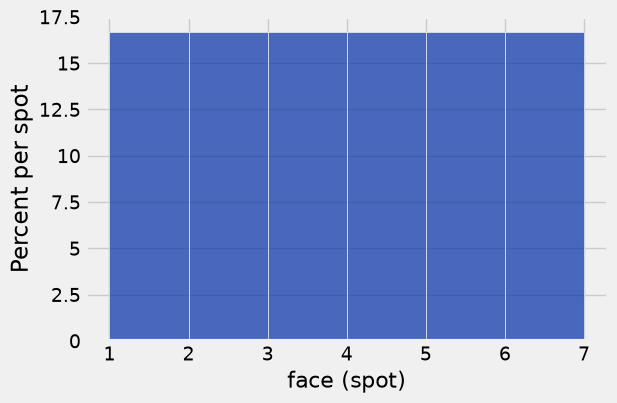

In [13]:
die.hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit = 'spot')

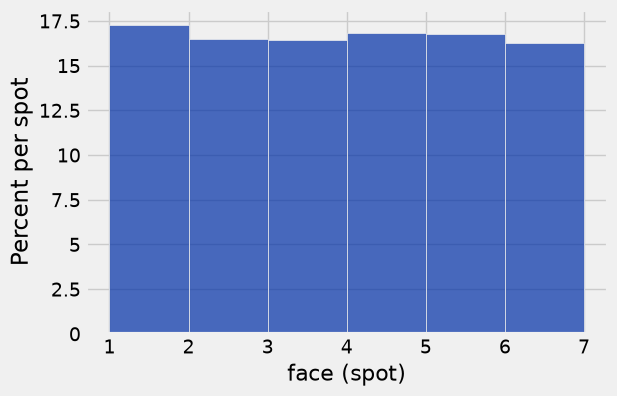

In [14]:
die.sample(10000).hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit = 'spot')

## Law of Averages / Law of Large Numbers
- if a chance experiment is reapeated many times independantly and under the same conditions, then the proportion of times that an eent occurs gets closer to the theoretical probability of the event
- if the sample size is large then the imperical distribition of a uniform random sample resembles the distribution of the population with high probabiliy

### distribution of delay on united flights

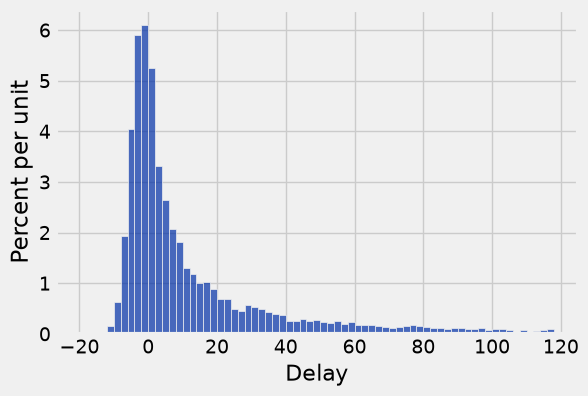

In [15]:
united_bins = np.arange(-20, 120, 2)
united.hist('Delay', bins = united_bins)

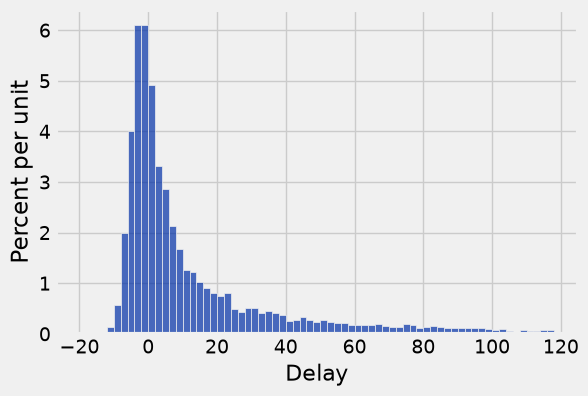

In [16]:
## sample a few
united.sample(13000).hist('Delay', bins = united_bins)

## Quantaties 

In [17]:
np.median(united.column('Delay'))

2.0

In [18]:
np.median(united.sample(10).column('Delay'))

1.0

In [19]:
def osm(sample_size):
   return np.median(united.sample(sample_size).column('Delay'))

In [20]:
osm(1000)

3.0

In [21]:
def osmd(repititions, sample_size):
    osms = make_array()

    for i in np.arange(repititions):
        new_median = osm(sample_size)
        osms = np.append(osms, new_median)

    return osms

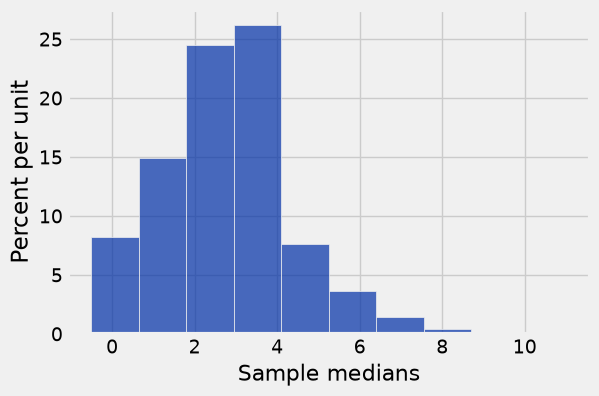

In [23]:
results = osmd(1000, 100)
Table().with_columns('Sample medians', results).hist()